# 0 &middot; Discretizing a Deformation &mdash; the Finite Element Method

The most basic question in solid mechanics is **how does this shape deform?** Answering it means
giving every material point $\bar x$ a **displacement** $u(\bar x)$, which defines the deformation map
below. A computer cannot store $u$ at infinitely many points, so we **discretize** it with the finite
element method (FEM), which every later tutorial builds on.

$$ \phi(\bar x) = \bar x + u(\bar x) $$

Imports, and every tunable parameter of this notebook.

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.colors import LogNorm
import igl
import simkit
import utils

NOTEBOOK = "000_finite_element_intuition"                       # this file's name
RESULTS_DIR = utils.notebook_results_path(NOTEBOOK)               # results/000_finite_element_intuition/
MEDIA_DIR = "media"                                               # tracked copies for the website
# meshes of the heart: (outline samples, max triangle area) passed to simkit.shape_mesh
FINE_MESH = (360, 6e-4)                                  # fine enough to look smooth
COARSE_MESH = (28, 6e-2)                                 # deliberately coarse FEM mesh
MESH_LEVELS = [(18, 0.2), (30, 0.04), (55, 0.01), (110, 0.003)]   # refinement sweep
# deformation
BEND_K = 0.7                                             # curvature of the bend phi
# single-triangle demos
HAT_TRI = np.array([[0.0, 0.0], [1.0, 0.0], [0.42, 0.92]])        # triangle for the basis-function plots
HAT_SUBDIVS = 5                                          # subdivisions of HAT_TRI for smooth color
V_TRI = np.array([[0.0, 0.0], [1.7, 0.15], [0.65, 1.45]])         # triangle for the vector blend
U_TRI = np.array([[0.28, -0.30], [0.42, 0.22], [-0.18, 0.46]])    # one displacement per corner
BARY_KEYS = np.array([[0.34, 0.33, 0.33], [0.86, 0.07, 0.07],     # barycentric keyframes of the
                      [0.34, 0.33, 0.33], [0.07, 0.86, 0.07],     # moving point: centre, near each
                      [0.34, 0.33, 0.33], [0.07, 0.07, 0.86],     # corner in turn, back to centre
                      [0.34, 0.33, 0.33]])
FRAMES_PER_KEY = 26                                      # frames between consecutive keyframes
# visuals
ERROR_SUBDIVS = 4                                        # subdivisions of each mesh where the error is sampled
N_ARROWS = 60                                            # displacement arrows drawn on the heart
MORPH_FRAMES = 36                                        # frames of the rest -> deformed morph
FPS = 20                                                 # video frame rate
HEART_FACE = "#fbb4b9"                                   # soft pink fill
HEART_EDGE = "#c51b8a"                                   # magenta edges / arrows

## A shape we build ourselves

No mesh files: the shape is the classic heart curve, divided by 16 so it spans $x \in [-1, 1]$,
$$ x(t) = 16\sin^3 t,\qquad y(t) = 13\cos t - 5\cos 2t - 2\cos 3t - \cos 4t. $$
`heart_outline` samples it into a closed polyline and `simkit.shape_mesh` fills the interior with
quality triangles (Triangle flags: `q` quality, `Q` quiet, `a` max area). This fine mesh plays the role
of the continuous shape.

In [2]:
def heart_outline(n):
    """n samples of the heart curve (x in [-1, 1]) and the closed edge list joining them."""
    t = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    x = np.sin(t) ** 3
    y_1 = 13.0 * np.cos(t)
    y_2 = -5.0 * np.cos(2 * t)
    y_3 = -2.0 * np.cos(3 * t)
    y_4 = -np.cos(4 * t)
    y = (y_1 + y_2 + y_3 + y_4) / 16.0
    Xs = np.column_stack([x, y])
    Es = simkit.closed_polyline(Xs)
    return Xs, Es

X, T, _, _ = simkit.shape_mesh(heart_outline, f"qQa{FINE_MESH[1]}", FINE_MESH[0])
print(f"smooth heart: {X.shape[0]} vertices, {T.shape[0]} triangles")

smooth heart: 3173 vertices, 5942 triangles


## A deformation we know everywhere

For $\phi$ we pick a gentle **bend** that curls the heart about its vertical axis. It is an analytic
map, so we can evaluate the true displacement $u(\bar x) = \phi(\bar x) - \bar x$ at **any** point we
like, which is exactly the luxury a computer does not have. The figure draws the fine mesh without
edges, so both shapes look like smooth, continuous blobs (no triangles in sight... yet).

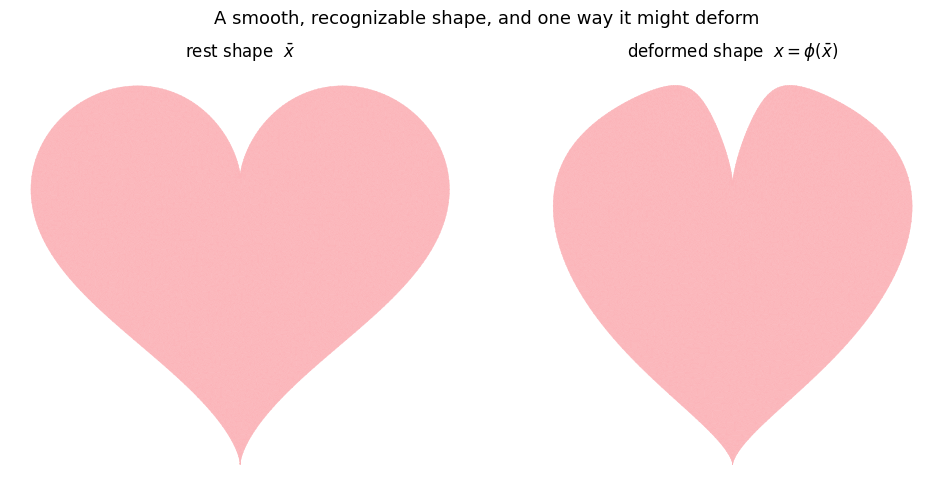

In [3]:
def deform(P, k=BEND_K):
    """The TRUE smooth deformation map phi at points P: bend about the axis x = 0 with curvature k."""
    if k == 0:
        return P.copy()
    R = 1.0 / k
    s = P[:, 0]                  # position along the bending axis
    h = P[:, 1]                  # height above the axis
    theta = s / R                # bend angle grows with arc length
    r = R - h
    return np.column_stack([r * np.sin(theta), R - r * np.cos(theta)])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, U, title in [(axes[0], X, r"rest shape  $\bar{x}$"),
                     (axes[1], deform(X), r"deformed shape  $x = \phi(\bar{x})$")]:
    utils.plot_mesh(ax, U, T, facecolor=HEART_FACE, edgecolor=HEART_FACE, lw=0.3, title=title)
    ax.axis("off")
fig.suptitle("A smooth, recognizable shape, and one way it might deform", fontsize=13)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "teaser.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_teaser.png"))
plt.show()

## The deformation *is* a vector field

$\phi$ carries one arrow $u(\bar x)$ per material point: which way, and how far, it moves. Left, a
spread-out subset of those arrows (picked with `simkit.farthest_point_sampling`); right, their length
$\|u\|$ as a color. Points on the vertical axis (bottom tip included) do not move at all, while the
lobes sweep inward and up as the heart curls. Finding this field is the problem we want to solve.

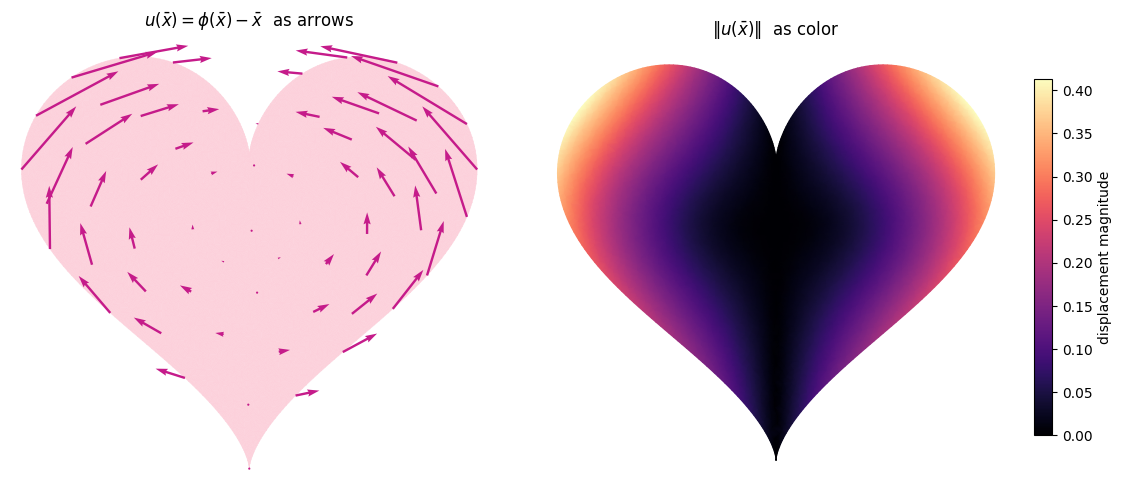

In [4]:
disp = deform(X) - X                                        # u(x) = phi(x) - x at every fine vertex
arrows = simkit.farthest_point_sampling(X, N_ARROWS)        # evenly spread arrow positions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
lims_field = utils.auto_limits([X, X + disp], pad=0.05)     # room for the arrow tips
utils.plot_mesh(axes[0], X, T, facecolor="#fcd0db", edgecolor="#fcd0db", lw=0.3, lims=lims_field,
                title=r"$u(\bar{x}) = \phi(\bar{x}) - \bar{x}$  as arrows")
axes[0].quiver(X[arrows, 0], X[arrows, 1], disp[arrows, 0], disp[arrows, 1], angles="xy",
               scale_units="xy", scale=1, color=HEART_EDGE, width=0.005, zorder=5)
utils.plot_scalar_field(axes[1], X, T, np.linalg.norm(disp, axis=1), edges=False, cmap="magma",
                        lims=lims_field, title=r"$\|u(\bar{x})\|$  as color", label="displacement magnitude")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "field.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_field.png"))
plt.show()

The video scales the field from $0$ to $1$: each arrow starts at its rest point $\bar x$ and its tip
rides along with the material to $\bar x + t\,u(\bar x)$.

In [5]:
ts = 0.5 * (1 - np.cos(np.linspace(0, np.pi, MORPH_FRAMES)))   # smooth ease 0 -> 1
states = [X + t * disp for t in ts]
fig, anim = utils.animate_mesh_arrows(states, T, X[arrows], [t * disp[arrows] for t in ts],
                                      facecolor=HEART_FACE, arrow_color=HEART_EDGE,
                                      title="the field carries every point from rest to deformed")
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "morph.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "000_morph.mp4"))
plt.close(fig)
utils.embed_video(video)

## The catch: there are infinitely many points

A smooth shape has a continuum of material points, but a computer needs a finite list of unknowns.
The finite element method gets one in three steps. The cell does the first two on a deliberately coarse
mesh of the same heart, so the elements are big, and marks the vertices (dots) where $u$ will live.

1. **Triangulate** the shape into a mesh of triangles (the *elements*).
2. Store $u$ **only at the vertices**: a finite set of unknowns.
3. Get $u$ **anywhere else** by *interpolating* the corner values across each triangle.

coarse FEM mesh: 49 vertices, 68 triangles -> 98 unknowns (u_x, u_y per vertex) instead of infinitely many


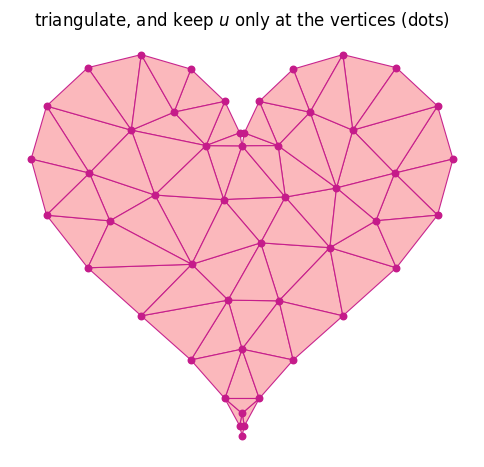

In [6]:
Xc, Tc, _, _ = simkit.shape_mesh(heart_outline, f"qQa{COARSE_MESH[1]}", COARSE_MESH[0])
print(f"coarse FEM mesh: {Xc.shape[0]} vertices, {Tc.shape[0]} triangles "
      f"-> {Xc.size} unknowns (u_x, u_y per vertex) instead of infinitely many")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
utils.plot_mesh(ax, Xc, Tc, facecolor=HEART_FACE, edgecolor=HEART_EDGE,
                title="triangulate, and keep $u$ only at the vertices (dots)")
ax.scatter(Xc[:, 0], Xc[:, 1], s=22, color=HEART_EDGE, zorder=6)
ax.axis("off")
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "mesh.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_mesh.png"))
plt.show()

## Inside one triangle: barycentric interpolation

Every point $\bar x$ of a triangle with corners $\bar x_0, \bar x_1, \bar x_2$ has unique
**barycentric coordinates** $(\lambda_0, \lambda_1, \lambda_2)$ with
$$ \bar x = \lambda_0 \bar x_0 + \lambda_1 \bar x_1 + \lambda_2 \bar x_2,
\qquad \lambda_0 + \lambda_1 + \lambda_2 = 1,\quad \lambda_i \ge 0. $$
The $\lambda_i$ are the triangle's **linear (P1) basis functions** $\phi_i$: $1$ at their own vertex,
$0$ at the other two, linear in between. The cell computes them with libigl at the vertices of a finely
subdivided triangle, checks that they sum to one, and colors each $\phi_i$ over the triangle.

561 sample points; partition of unity: max |phi_0 + phi_1 + phi_2 - 1| = 1.1e-16


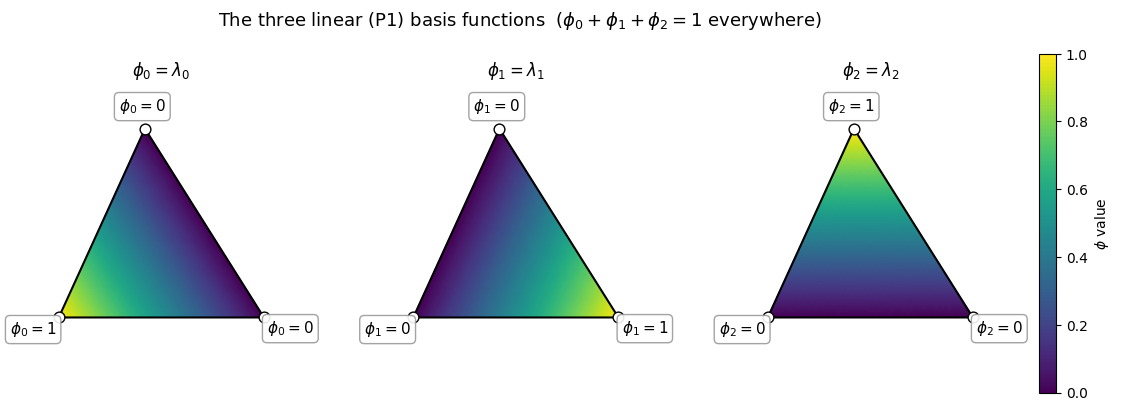

In [7]:
def barycentric(P, tri):
    """Barycentric coordinates (m, 3) of points P (m, 2) in the single triangle tri (3, 2)."""
    A, B, C = (np.repeat(tri[[i]], len(P), axis=0) for i in range(3))
    return igl.barycentric_coordinates(P, A, B, C)

P, Fp = igl.upsample(HAT_TRI, np.array([[0, 1, 2]]), HAT_SUBDIVS)   # sample points filling the triangle
lam = barycentric(P, HAT_TRI)
print(f"{len(P)} sample points; partition of unity: max |phi_0 + phi_1 + phi_2 - 1| = "
      f"{np.abs(lam.sum(axis=1) - 1).max():.1e}")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
centroid = HAT_TRI.mean(axis=0)
for k, ax in enumerate(axes):
    m = utils.plot_scalar_field(ax, P, Fp, lam[:, k], vmin=0, vmax=1, edges=False, colorbar=False,
                                lims=utils.auto_limits([HAT_TRI], pad=0.22),
                                title=rf"$\phi_{k} = \lambda_{k}$")
    ax.plot(*HAT_TRI[[0, 1, 2, 0]].T, "k", lw=1.5)
    for v in range(3):                                  # value label, nudged outward from the centre
        d = (HAT_TRI[v] - centroid) / np.linalg.norm(HAT_TRI[v] - centroid)
        ax.scatter(*HAT_TRI[v], s=60, color="white", edgecolor="k", zorder=5)
        ax.annotate(rf"$\phi_{k}={1 if v == k else 0}$", HAT_TRI[v], textcoords="offset points",
                    xytext=(22 * d[0], 16 * d[1]), ha="center", va="center", fontsize=11, zorder=6,
                    bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=0.9))
    ax.axis("off")
fig.colorbar(m, ax=axes, fraction=0.02, pad=0.02, label=r"$\phi$ value")
fig.suptitle(r"The three linear (P1) basis functions  ($\phi_0 + \phi_1 + \phi_2 = 1$ everywhere)",
             fontsize=13)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "hats.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_hats.png"))
plt.show()

## Combining the hats into a *vector* interpolation

Give each corner its own displacement vector $u_0, u_1, u_2$. The displacement at any interior point
is the basis-weighted blend
$$ u(\bar x) = \sum_i \phi_i(\bar x)\, u_i = \lambda_0 u_0 + \lambda_1 u_1 + \lambda_2 u_2. $$
The cell moves a point through the triangle, recovers its $\lambda$ from its position alone (the
printed error checks this), and blends the corner vectors. In the video the point's arrow (orange)
rebalances between the corner arrows (blue), and near a vertex it approaches that vertex's arrow.

In [8]:
path_bary = np.vstack([np.linspace(BARY_KEYS[i], BARY_KEYS[i + 1], FRAMES_PER_KEY, endpoint=False)
                       for i in range(len(BARY_KEYS) - 1)])
path_xy = path_bary @ V_TRI                              # the moving point  x = sum_i lambda_i x_i
lam_path = barycentric(path_xy, V_TRI)                   # recovered from the position alone
u_path = lam_path @ U_TRI                                # u(x) = lambda_0 u_0 + lambda_1 u_1 + lambda_2 u_2
print(f"{len(path_xy)} frames; max |lambda recovered - lambda true| = "
      f"{np.abs(lam_path - path_bary).max():.1e}")

texts = [f"lambda = ({l[0]:.2f}, {l[1]:.2f}, {l[2]:.2f})\n"
         f"u(x)   = {l[0]:.2f} u0 + {l[1]:.2f} u1 + {l[2]:.2f} u2" for l in lam_path]
fig, anim = utils.animate_triangle_blend(V_TRI, U_TRI, path_xy, u_path, texts)
fig.axes[0].texts[1].set_position(V_TRI[1] + np.array([0.02, -0.15]))   # move the u_1 label off its arrow
video = simkit.filesystem.save_animation(anim, os.path.join(RESULTS_DIR, "interp.mp4"), fps=FPS,
                                         copy_to=os.path.join(MEDIA_DIR, "000_interp.mp4"))
plt.close(fig)
utils.embed_video(video)

156 frames; max |lambda recovered - lambda true| = 3.3e-16


## The whole shape: store at vertices, interpolate inside

Apply this to every triangle at once: sample $u$ **only at the vertices** of a mesh and let each
triangle interpolate its three corner vectors. That is a full finite-element deformation, with no
solver and no energy. Top row: the rest meshes of the
refinement sweep; bottom row: their FEM deformations. As the mesh is refined, the piecewise-linear
shape approaches the smooth limit (right).

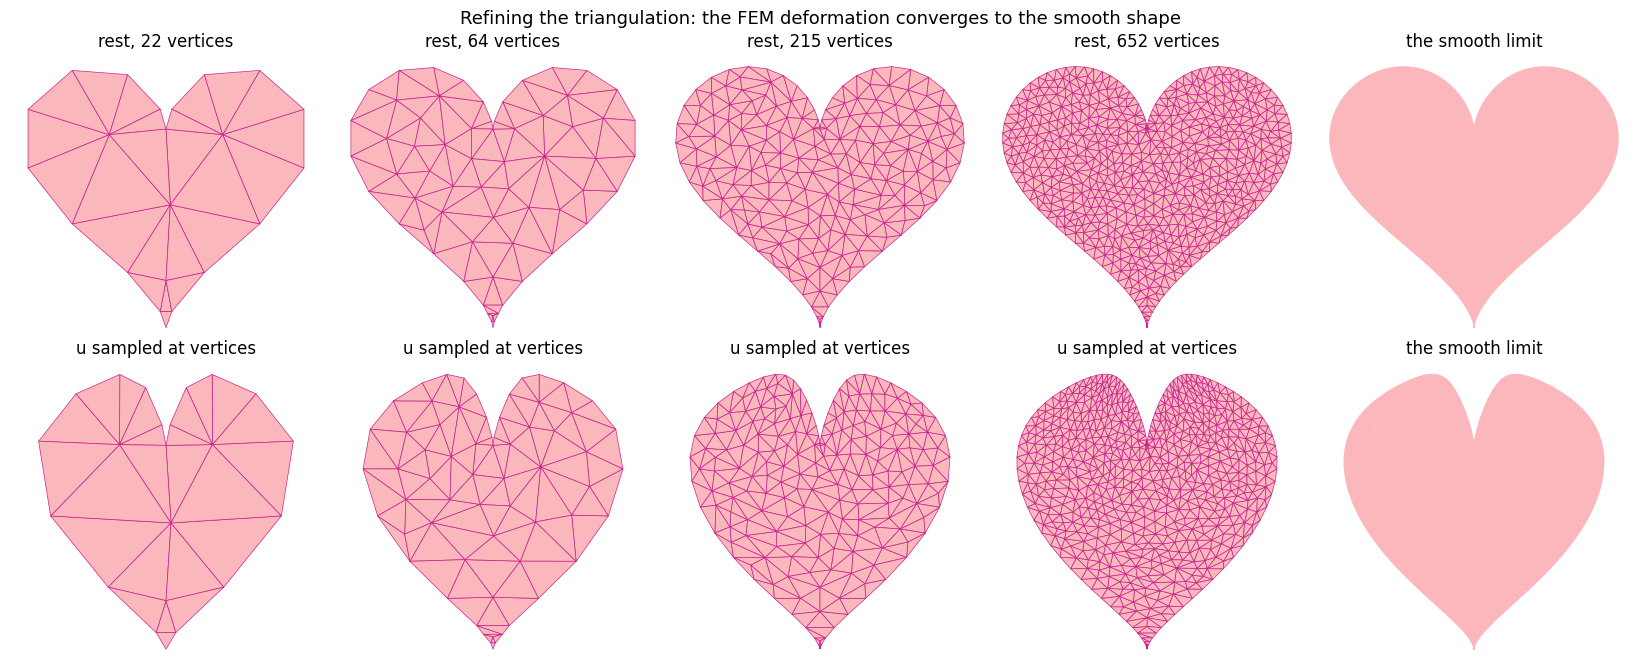

In [9]:
meshes = [simkit.shape_mesh(heart_outline, f"qQa{a}", n)[:2] for n, a in MESH_LEVELS]
lims_rest = utils.auto_limits([X], pad=0.08)
lims_def = utils.auto_limits([deform(X)], pad=0.08)

fig, axes = plt.subplots(2, len(meshes) + 1, figsize=(3.3 * (len(meshes) + 1), 6.8))
for j, (V, F) in enumerate(meshes):
    utils.plot_mesh(axes[0, j], V, F, facecolor=HEART_FACE, edgecolor=HEART_EDGE, lw=0.5,
                    lims=lims_rest, title=f"rest, {V.shape[0]} vertices")
    utils.plot_mesh(axes[1, j], deform(V), F, facecolor=HEART_FACE, edgecolor=HEART_EDGE, lw=0.5,
                    lims=lims_def, title="u sampled at vertices")
utils.plot_mesh(axes[0, -1], X, T, facecolor=HEART_FACE, edgecolor=HEART_FACE, lw=0.3,
                lims=lims_rest, title="the smooth limit")
utils.plot_mesh(axes[1, -1], deform(X), T, facecolor=HEART_FACE, edgecolor=HEART_FACE, lw=0.3,
                lims=lims_def, title="the smooth limit")
for ax in axes.ravel():
    ax.axis("off")
fig.suptitle("Refining the triangulation: the FEM deformation converges to the smooth shape", fontsize=13)
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "convergence.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_convergence.png"))
plt.show()

## How good is the interpolation?

`p1_interpolate` evaluates the FEM interpolant at arbitrary points: find the triangle that contains
each point, take its barycentric coordinates, and blend the three corner values (one line per corner).
`interpolation_error` stores the true $u$ only at a mesh's vertices and compares $u_h$ with the true
$u$ at the centroids of a finely subdivided copy of that mesh. The cell first checks that $u_h = u$
exactly at the vertices, then measures the coarse mesh from above (drawn next to its triangle areas)
and the refinement sweep.

coarse mesh: error at its own vertices 0.0e+00, max error inside 2.46e-02
   22 vertices: max error 4.91e-02, L2 error 1.99e-02
   64 vertices: max error 1.32e-02, L2 error 4.58e-03
  215 vertices: max error 4.22e-03, L2 error 1.25e-03
  652 vertices: max error 1.24e-03, L2 error 3.46e-04
fitted slope of L2 error vs N: -1.18  (P1 theory: -1, i.e. O(h^2))


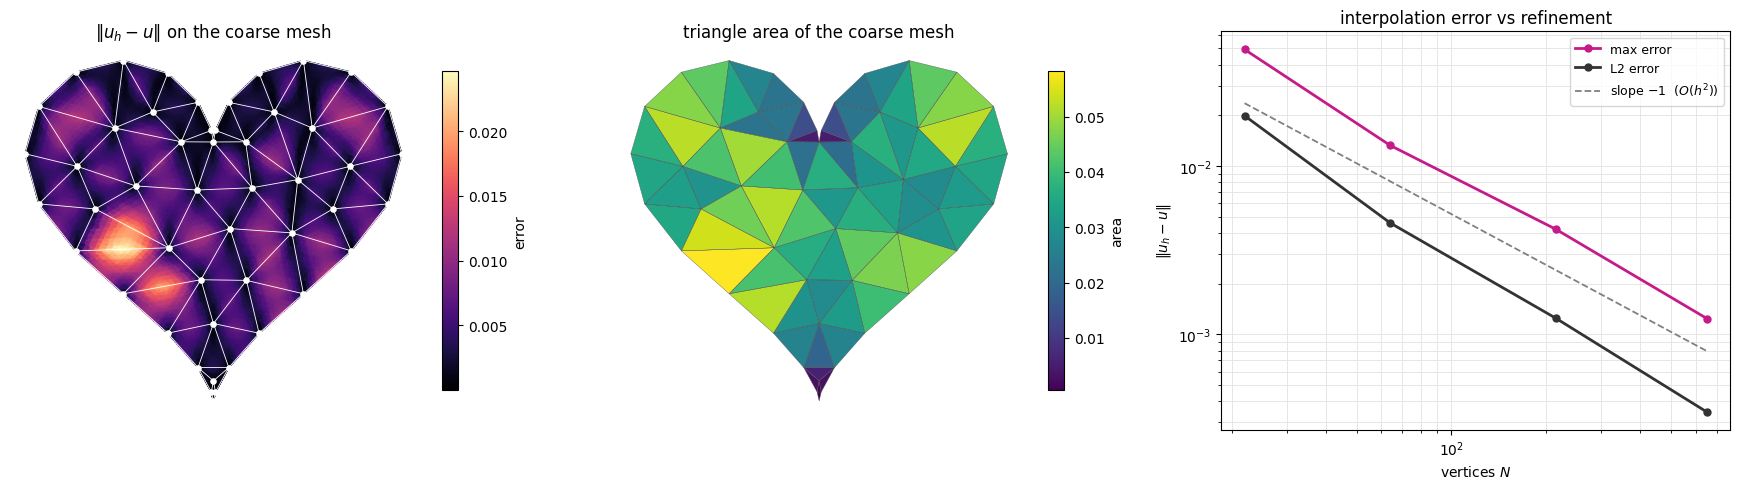

In [10]:
def p1_interpolate(Q, V, F, U):
    """FEM (P1) interpolant of per-vertex values U (n, d) at query points Q (q, 2); NaN outside the mesh."""
    e = mtri.Triangulation(V[:, 0], V[:, 1], F).get_trifinder()(Q[:, 0], Q[:, 1])   # containing triangle, -1 outside
    inside = e >= 0
    Fe = F[e[inside]]                                     # corners of each point's triangle
    lam = igl.barycentric_coordinates(Q[inside], V[Fe[:, 0]], V[Fe[:, 1]], V[Fe[:, 2]])
    u_0 = lam[:, [0]] * U[Fe[:, 0]]                       # corner 0's share
    u_1 = lam[:, [1]] * U[Fe[:, 1]]                       # corner 1's share
    u_2 = lam[:, [2]] * U[Fe[:, 2]]                       # corner 2's share
    u_total = u_0 + u_1 + u_2
    U_h = np.full((len(Q), U.shape[1]), np.nan)
    U_h[inside] = u_total
    return U_h

def interpolation_error(V, F):
    """|u_h - u| at the centroids of a subdivided copy (Vs, Fs) of mesh (V, F); u_h knows u at V only."""
    Vs, Fs = igl.upsample(V, F, ERROR_SUBDIVS)
    Q = Vs[Fs].mean(axis=1)                               # centroids: each strictly inside one triangle
    U_h = p1_interpolate(Q, V, F, deform(V) - V)
    err = np.linalg.norm(U_h - (deform(Q) - Q), axis=1)
    return err, Vs, Fs

U_own = p1_interpolate(Xc, Xc, Tc, deform(Xc) - Xc)       # evaluate at the mesh's own vertices
err_c, Vs_c, Fs_c = interpolation_error(Xc, Tc)
print(f"coarse mesh: error at its own vertices {np.abs(U_own - (deform(Xc) - Xc)).max():.1e}, "
      f"max error inside {err_c.max():.2e}")

n_verts, err_max, err_l2, sweep = [], [], [], []
for V, F in meshes:
    err, Vs, Fs = interpolation_error(V, F)
    area = simkit.triangle_areas(Vs, Fs).ravel()
    sweep.append((V, F, Vs, Fs, err))                     # kept for the per-level error figure below
    n_verts.append(V.shape[0])
    err_max.append(err.max())
    err_l2.append(np.sqrt(np.sum(area * err ** 2) / np.sum(area)))   # area-weighted RMS (L2) error
    print(f"{V.shape[0]:5d} vertices: max error {err_max[-1]:.2e}, L2 error {err_l2[-1]:.2e}")
slope = np.polyfit(np.log(n_verts), np.log(err_l2), 1)[0]
print(f"fitted slope of L2 error vs N: {slope:.2f}  (P1 theory: -1, i.e. O(h^2))")

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5))
m = utils.plot_scalar_field(axes[0], Vs_c, Fs_c, err_c, edges=False, cmap="magma", lims=lims_rest,
                            title=r"$\|u_h - u\|$ on the coarse mesh", label="error")
m.set_edgecolor("face")                                   # hide seams between the flat sub-triangles
axes[0].triplot(Xc[:, 0], Xc[:, 1], Tc, color="white", lw=0.6)
axes[0].scatter(Xc[:, 0], Xc[:, 1], s=14, color="white", zorder=6)
utils.plot_scalar_field(axes[1], Xc, Tc, simkit.triangle_areas(Xc, Tc).ravel(), cmap="viridis",
                        lims=lims_rest, title="triangle area of the coarse mesh", label="area")
for ax in axes[:2]:
    ax.axis("off")
utils.loglog_plot(n_verts, {"max error": err_max, "L2 error": err_l2}, ax=axes[2],
                  colors={"max error": HEART_EDGE, "L2 error": "0.2"},
                  ref_slopes={r"slope $-1$  ($O(h^2)$)": -1}, xlabel="vertices $N$",
                  ylabel=r"$\|u_h - u\|$", title="interpolation error vs refinement")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "interp_error.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_interp_error.png"))
plt.show()

Left: the error vanishes at the vertices (white dots) and peaks halfway along the edges, most along the
long edges of the largest triangles (middle). Right: it falls like $N^{-1}$, i.e. $O(h^2)$ in the element
size $h \sim N^{-1/2}$, as expected for linear interpolation.

The cell draws the same error field on every level of the refinement sweep, on one logarithmic color
scale: it darkens by about $4\times$ per level, matching the L2 errors printed above.

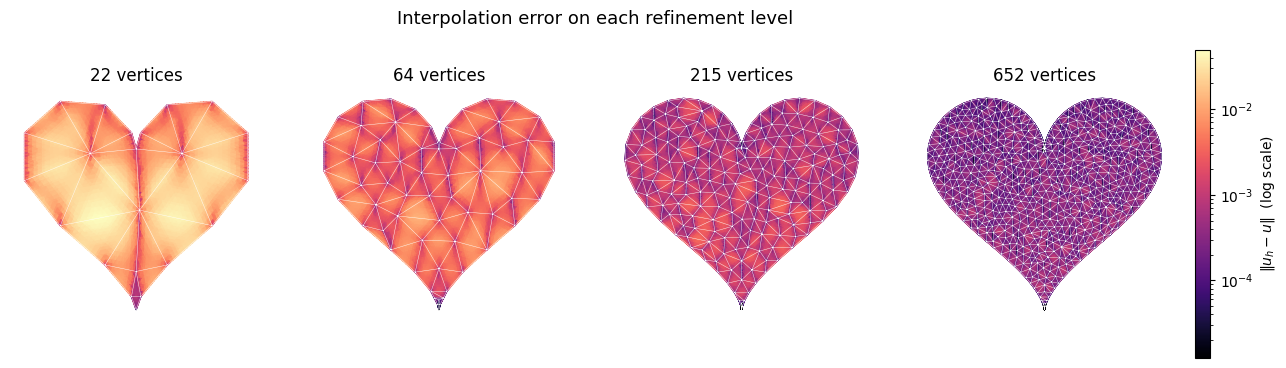

In [11]:
fig, axes = plt.subplots(1, len(sweep), figsize=(3.6 * len(sweep) + 1.2, 4))
norm = LogNorm(vmin=err_max[-1] / 100, vmax=err_max[0])   # shared scale, finest level to coarsest
for ax, (V, F, Vs, Fs, err) in zip(axes, sweep):
    m = utils.plot_scalar_field(ax, Vs, Fs, err, norm=norm, cmap="magma", edges=False, colorbar=False,
                                lims=lims_rest, title=f"{V.shape[0]} vertices")
    m.set_edgecolor("face")                               # hide seams between the flat sub-triangles
    ax.triplot(V[:, 0], V[:, 1], F, color="white", lw=0.3)
    ax.axis("off")
fig.colorbar(m, ax=axes, fraction=0.02, pad=0.02, label=r"$\|u_h - u\|$  (log scale)")
fig.suptitle("Interpolation error on each refinement level", fontsize=13)
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "sweep_error.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_sweep_error.png"))
plt.show()

## It was triangles all along

Finally, turn the edges of the fine "smooth" heart back **on**: the deforming shape from the very first
figure was a triangle mesh the entire time.

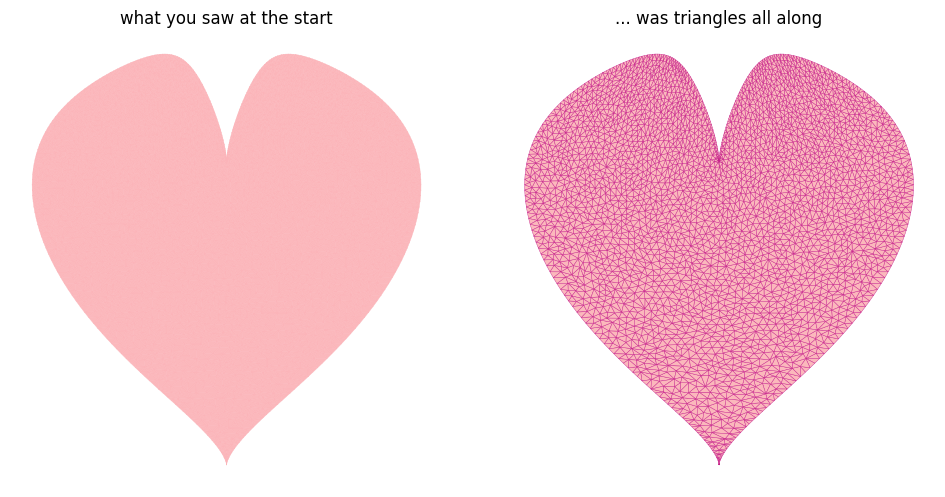

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
utils.plot_mesh(axes[0], deform(X), T, facecolor=HEART_FACE, edgecolor=HEART_FACE, lw=0.3,
                title="what you saw at the start")
utils.plot_mesh(axes[1], deform(X), T, facecolor=HEART_FACE, edgecolor=HEART_EDGE, lw=0.3,
                title="... was triangles all along")
for ax in axes:
    ax.axis("off")
fig.tight_layout()
simkit.filesystem.save_figure(fig, os.path.join(RESULTS_DIR, "reveal.png"),
                              copy_to=os.path.join(MEDIA_DIR, "000_reveal.png"))
plt.show()

### Takeaways

* "How does this shape deform?" asks for a **displacement field** $u(\bar x)$, one arrow per material point.
* FEM **discretizes** it: triangulate, store $u$ **only at the vertices**, and interpolate inside each
  triangle with the P1 basis, $u(\bar x) = \sum_i \phi_i(\bar x)\, u_i$. The interpolant is exact at the
  vertices and its error shrinks like $O(h^2)$ as the mesh is refined.
* Next, the tutorials measure how stretched each element is (the **deformation gradient**, tutorial 1),
  turn that into an **elastic energy**, and **minimize** it to actually *find* $u$.
* FEM is one discretization among many: Gaussian splats, RKPM and other meshless methods, point clouds,
  signed distance fields, spline patches, neural fields. Choosing the right one for a given geometry is
  still open research.